In [7]:
import numpy as np
import matplotlib.pyplot as plt
import gc

## 1. Fashion MNIST Sample 그려보기

각 class 별로 한 개 씩의 sample을 뽑아서 그림을 그려봅니다.

In [8]:
import tensorflow as tf
from tensorflow.keras import datasets, models, Input
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPool2D

# 재현성을 위해 시드 고정 (환경에 따라 결과는 달라질 수 있음)
tf.keras.utils.set_random_seed(42)
print(tf.__version__)

2.21.0


In [9]:
# Fashion MNIST 불러오기
fashion_mnist = datasets.fashion_mnist
(train_x, train_y), (test_x, test_y) = fashion_mnist.load_data()
# 학습 및 테스트 이미지 정규화
train_x = train_x.astype('float32') / 255.0
test_x = test_x.astype('float32') / 255.0

# 학습 및 테스트 데이터의 이미지와 정답 레이블 배열 형태(shape) 확인
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


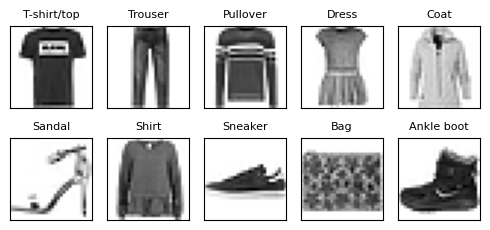

In [10]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

plt.figure(figsize=(5, 2.5))

for class_id in range(10):
    # 해당 클래스에 속하는 첫 번째 이미지의 인덱스
    index = np.where(train_y == class_id)[0][0]

    plt.subplot(2, 5, class_id + 1)
    plt.imshow(train_x[index], cmap=plt.cm.binary)
    plt.title(class_names[class_id], fontsize=8)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

## 2. Fashion MNIST(or CIFAR10)를 분류하는 CNN 학습하기

CNN이 image data에서 DNN에 비해 얼마나 뛰어난지를 확인하는 것이 목표입니다.  
모수의 수가 비슷한 DNN과 CNN을 구축한 뒤 데이터를 이용하여 각각의 모형을 학습하고 test accuracy를 비교합니다.

In [11]:
## DNN model을 구축합니다.
dnn_model = models.Sequential([
  Input(shape=(28, 28)),
  Flatten(),
  Dense(110, activation='relu'),
  Dense(100, activation='relu'),
  Dense(10, activation='softmax')]
)

dnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 110)            │        86,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        11,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,460 (384.61 KB)

 Trainable params: 98,460 (384.61 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Adam 최적화 알고리즘과 정수 레이블용 다중 분류 손실 함수를 설정하고, 정확도로 성능 평가
dnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 학습 데이터의 10%를 검증용으로 분리하고, 나머지를 배치 크기 100으로 20회 학습하여 기록 저장
dnn_hist = dnn_model.fit(train_x, train_y, epochs=20, batch_size=100, validation_split=0.10)

Epoch 1/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8093 - loss: 0.5435 - val_accuracy: 0.8487 - val_loss: 0.4197
Epoch 2/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8613 - loss: 0.3847 - val_accuracy: 0.8645 - val_loss: 0.3740
Epoch 3/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8748 - loss: 0.3419 - val_accuracy: 0.8688 - val_loss: 0.3591
Epoch 4/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8847 - loss: 0.3165 - val_accuracy: 0.8728 - val_loss: 0.3459
Epoch 5/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8911 - loss: 0.2974 - val_accuracy: 0.8707 - val_loss: 0.3516
Epoch 6/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8962 - loss: 0.2823 - val_accuracy: 0.8793 - val_loss: 0.3413
Epoch 7/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9001 - loss: 0.2703 - val_accuracy: 0.8790 - val_loss: 0.3474
Epoch 8/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9042 - loss: 0.2581 - val_accuracy: 0.

In [13]:
# DNN 모델을 평가합니다.
dnn_sc = dnn_model.evaluate(test_x, test_y)

print('Performance of DNN')
print('...test accuracy: %.3f, test loss: %.3f'%(dnn_sc[1], dnn_sc[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8713 - loss: 0.4300  
Performance of DNN
...test accuracy: 0.871, test loss: 0.430


In [14]:
# CNN 모델에서 사용하기 위해 Data shape을 변경합니다.
ext_train_x = train_x.reshape((60000, 28, 28, 1))
ext_test_x = test_x.reshape((10000, 28, 28, 1))

In [15]:
## CNN model을 구축합니다.
fashion_cnn_model = models.Sequential([
  Input(shape=(28, 28, 1)),
  Conv2D(32, (3, 3), activation='relu'),
  MaxPool2D(pool_size=(2, 2), strides=(2,2), padding='valid'),
  Conv2D(64, (3, 3), activation='relu'),
  MaxPool2D(pool_size=(2, 2), strides=(2,2), padding='valid'),
  Conv2D(64, (3, 3), activation='relu'),
  Flatten(),
  Dense(64, activation='relu'),
  Dense(10, activation='softmax')
])

fashion_cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Adam 최적화 알고리즘과 정수 레이블용 다중 분류 손실 함수를 설정하고, 정확도로 성능 평가
fashion_cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 학습 데이터의 10%를 검증용으로 분리하고, 나머지를 배치 크기 100으로 20회 학습하여 기록 저장
fashion_cnn_hist=fashion_cnn_model.fit(ext_train_x, train_y, epochs=20, batch_size=100, validation_split=0.10)

Epoch 1/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7791 - loss: 0.6056 - val_accuracy: 0.8442 - val_loss: 0.4538
Epoch 2/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8643 - loss: 0.3764 - val_accuracy: 0.8687 - val_loss: 0.3784
Epoch 3/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8828 - loss: 0.3248 - val_accuracy: 0.8792 - val_loss: 0.3380
Epoch 4/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8924 - loss: 0.2935 - val_accuracy: 0.8857 - val_loss: 0.3157
Epoch 5/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9009 - loss: 0.2686 - val_accuracy: 0.8953 - val_loss: 0.2986
Epoch 6/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9087 - loss: 0.2479 - val_accuracy: 0.8987 - val_loss: 0.2892
Epoch 7/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9155 - loss: 0.2302 - val_accuracy: 0.9048 - val_loss: 0.2815
Epoch 8/20
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9214 - loss: 0.2141 - val_accu

In [17]:
# CNN 모델을 평가합니다.
fashion_cnn_sc = fashion_cnn_model.evaluate(ext_test_x, test_y)

print('Performance of CNN')
print('...test accuracy: %.3f, test loss: %.3f'%(fashion_cnn_sc[1], fashion_cnn_sc[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9034 - loss: 0.3995
Performance of CNN
...test accuracy: 0.903, test loss: 0.399


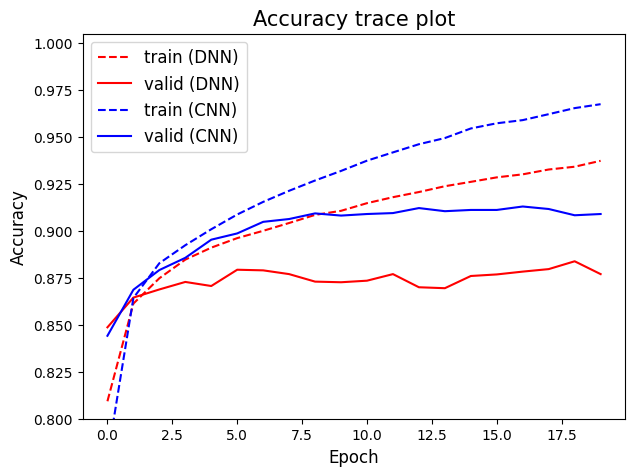

In [18]:
# DNN, CNN 모델의 결과를 비교합니다.
plt.figure(figsize=(7,5))
plt.plot(dnn_hist.history['accuracy'], 'r--', label='train (DNN)')
plt.plot(dnn_hist.history['val_accuracy'], 'r-', label='valid (DNN)')
plt.plot(fashion_cnn_hist.history['accuracy'], 'b--', label='train (CNN)')
plt.plot(fashion_cnn_hist.history['val_accuracy'], 'b-', label='valid (CNN)')
plt.ylim([0.8,1.005])
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.title('Accuracy trace plot', fontsize=15)
plt.show()

In [19]:
# 동일한 테스트 데이터에서 모수 수와 성능 비교
print(f"{'Model':<15} {'Parameters':>12} {'Test accuracy':>15} {'Test loss':>12}")
for name, model_obj, score in [('DNN', dnn_model, dnn_sc), ('CNN', fashion_cnn_model, fashion_cnn_sc)]:
    print(f'{name:<15} {model_obj.count_params():>12,} {score[1]:>14.2%} {score[0]:>12.4f}')
print(f'CNN - DNN 테스트 정확도 차이: {(fashion_cnn_sc[1] - dnn_sc[1]) * 100:+.2f}%p')

Model             Parameters   Test accuracy    Test loss
DNN                   98,460         87.13%       0.4300
CNN                   93,322         90.34%       0.3995
CNN - DNN 테스트 정확도 차이: +3.21%p


## 3. 전이학습 활용해보기

전이학습을 실제로 활용해보는 것을 목표로 합니다.  
InceptionV3을 이용하여 CIFAR10의 feature vector를 구축하고  
이 feature vector를 이용하여 multi-class logistic regression model을 학습합니다.  
이 모형의 결과를 앞서 CNN으로 학습한 모형의 결과와 비교해봅니다.

앞서 Fashion MNIST를 DNN, CNN으로 학습했습니다.  
전이학습결과와의 비교를 위해서 CIFAR10을 CNN으로 학습합니다.

In [20]:
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

In [21]:
# Fashion MNIST와 다른 변수에 이미지와 정답을 함께 저장합니다.
(cifar_train_x, cifar_train_y), (cifar_test_x, cifar_test_y) = datasets.cifar10.load_data()
cifar_train_y = cifar_train_y.reshape(-1)
cifar_test_y = cifar_test_y.reshape(-1)
print(cifar_train_x.shape, cifar_train_y.shape)
print(cifar_test_x.shape, cifar_test_y.shape)

d:\python313\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = RestrictedUnpickler(f, encoding="bytes").load()


(50000, 32, 32, 3) (50000,)
(10000, 32, 32, 3) (10000,)


In [22]:
# 배치별 확대 및 정규화로 큰 임시 배열의 메모리 사용을 줄입니다.
def resize_for_cnn(images, batch_size=256):
    result = np.empty((len(images), 75, 75, 3), dtype=np.float32)
    for start in range(0, len(images), batch_size):
        batch = tf.cast(images[start:start + batch_size], tf.float32)
        result[start:start + batch_size] = tf.image.resize(batch, (75, 75)).numpy() / 255.0
    return result

big_train_x = resize_for_cnn(cifar_train_x)
big_test_x = resize_for_cnn(cifar_test_x)
print(big_train_x.shape, big_test_x.shape)

(50000, 75, 75, 3) (10000, 75, 75, 3)


In [23]:
# 이미 0~1로 정규화했으므로 다시 255로 나누지 않습니다.
assert len(big_train_x) == len(cifar_train_y)
assert len(big_test_x) == len(cifar_test_y)
assert 0 <= big_train_x.min() <= big_train_x.max() <= 1
assert 0 <= big_test_x.min() <= big_test_x.max() <= 1
print('CNN 입력 범위:', big_train_x.min(), big_train_x.max())

CNN 입력 범위: 0.0 1.0


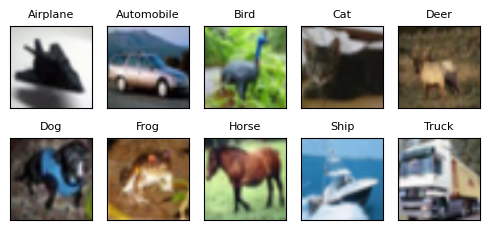

In [24]:
class_names = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

labels = np.asarray(cifar_train_y).reshape(-1)
plt.figure(figsize=(5, 2.5))

for class_id in range(10):
    # 해당 클래스에 속하는 첫 번째 이미지의 인덱스
    index = np.where(labels == class_id)[0][0]

    plt.subplot(2, 5, class_id + 1)
    plt.imshow(big_train_x[index])
    plt.title(class_names[class_id], fontsize=8)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

In [25]:
## CNN model을 구축합니다.
cifar_cnn_model = models.Sequential([
    Input(shape=(75, 75, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid'),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

cifar_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 73, 73, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       921,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 978,634 (3.73 MB)

 Trainable params: 978,634 (3.73 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Adam 최적화 알고리즘과 정수 레이블용 다중 분류 손실 함수를 설정하고, 정확도로 성능 평가
cifar_cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 학습 데이터의 10%를 검증용으로 분리하고, 나머지를 배치 크기 100으로 20회 학습하여 기록 저장
cifar_cnn_hist=cifar_cnn_model.fit(big_train_x, cifar_train_y, epochs=20, batch_size=100, validation_split=0.10)

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 48s 105ms/step - accuracy: 0.4431 - loss: 1.5471 - val_accuracy: 0.5586 - val_loss: 1.2641
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 46s 103ms/step - accuracy: 0.5905 - loss: 1.1609 - val_accuracy: 0.6264 - val_loss: 1.0597
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 47s 105ms/step - accuracy: 0.6590 - loss: 0.9752 - val_accuracy: 0.6598 - val_loss: 0.9893
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 46s 103ms/step - accuracy: 0.7028 - loss: 0.8546 - val_accuracy: 0.6722 - val_loss: 0.9718
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 48s 106ms/step - accuracy: 0.7347 - loss: 0.7648 - val_accuracy: 0.6764 - val_loss: 0.9764
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 47s 105ms/step - accuracy: 0.7627 - loss: 0.6892 - val_accuracy: 0.6842 - val_loss: 0.9795
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 47s 105ms/step - accuracy: 0.7856 - loss: 0.6244 - val_accuracy: 0.6902 - val_loss: 0.9907
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 47s 103ms/step - accuracy: 0.8064 - loss: 0

In [27]:
# CNN 모델을 평가합니다.
cifar_cnn_sc = cifar_cnn_model.evaluate(big_test_x, cifar_test_y)

print('Performance of CNN')
print('...test accuracy: %.3f, test loss: %.3f'%(cifar_cnn_sc[1], cifar_cnn_sc[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6379 - loss: 2.3866
Performance of CNN
...test accuracy: 0.638, test loss: 2.387


In [28]:
# 고정된 사전학습 특징 추출기: 이미지별 2048차원 벡터 출력
inception_model = InceptionV3(
    weights='imagenet', include_top=False,
    input_shape=(75, 75, 3), pooling='avg'
)
inception_model.trainable = False

In [29]:
# CNN용 0~1 데이터는 유지하고 배치별로 InceptionV3 전처리를 적용합니다.
def extract_features(images, batch_size=100):
    features = np.empty((len(images), 2048), dtype=np.float32)
    for start in range(0, len(images), batch_size):
        # preprocess_input은 0~255를 받아 -1~1로 변환합니다.
        batch = preprocess_input(images[start:start + batch_size] * 255.0)
        features[start:start + batch_size] = inception_model(batch, training=False).numpy()
        if start == 0 or (start + batch_size) % 5000 == 0:
            print(f'특징 추출: {min(start + batch_size, len(images))}/{len(images)}')
    return features

train_features = extract_features(big_train_x)
test_features = extract_features(big_test_x)
print(train_features.shape)  # (50000, 2048)
print(test_features.shape)   # (10000, 2048)

특징 추출: 100/50000
특징 추출: 5000/50000
특징 추출: 10000/50000
특징 추출: 15000/50000
특징 추출: 20000/50000
특징 추출: 25000/50000
특징 추출: 30000/50000
특징 추출: 35000/50000
특징 추출: 40000/50000
특징 추출: 45000/50000
특징 추출: 50000/50000
특징 추출: 100/10000
특징 추출: 5000/10000
특징 추출: 10000/10000
(50000, 2048)
(10000, 2048)


In [30]:
multi_logistic_model = models.Sequential([
  Input(shape=(2048,)),
  Dense(10, activation='softmax')]
)
multi_logistic_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,490 (80.04 KB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
multi_logistic_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

transfer_hist = multi_logistic_model.fit(train_features, cifar_train_y, epochs=20, batch_size=100, validation_split=0.10)

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5566 - loss: 1.3077 - val_accuracy: 0.6210 - val_loss: 1.1260
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6464 - loss: 1.0384 - val_accuracy: 0.6336 - val_loss: 1.0821
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6668 - loss: 0.9798 - val_accuracy: 0.6360 - val_loss: 1.0733
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6772 - loss: 0.9471 - val_accuracy: 0.6360 - val_loss: 1.0735
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6840 - loss: 0.9249 - val_accuracy: 0.6364 - val_loss: 1.0766
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6899 - loss: 0.9084 - val_accuracy: 0.6366 - val_loss: 1.0806
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6939 - loss: 0.8951 - val_accuracy: 0.6362 - val_loss: 1.0851
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6978 - loss: 0.8842 - val_accuracy: 0.

In [32]:
# CNN과 동일한 CIFAR-10 테스트 이미지 및 레이블로 평가합니다.
transfer_sc = multi_logistic_model.evaluate(test_features, cifar_test_y)
print(f"{'Model':<22} {'Test accuracy':>15} {'Test loss':>12}")
for name, score in [('CNN', cifar_cnn_sc), ('InceptionV3 + Logistic', transfer_sc)]:
    print(f'{name:<22} {score[1]:>14.2%} {score[0]:>12.4f}')
print(f'전이학습 - CNN 테스트 정확도 차이: {(transfer_sc[1] - cifar_cnn_sc[1]) * 100:+.2f}%p')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 899us/step - accuracy: 0.6372 - loss: 1.1284
Model                    Test accuracy    Test loss
CNN                            63.79%       2.3866
InceptionV3 + Logistic         63.72%       1.1284
전이학습 - CNN 테스트 정확도 차이: -0.07%p


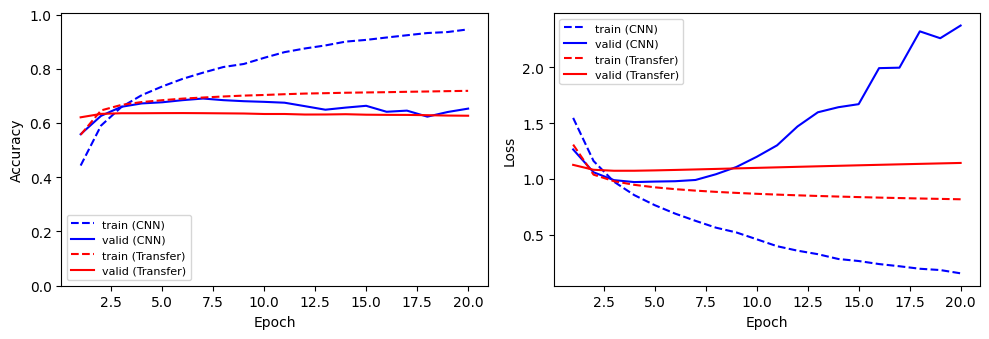

In [33]:
# 정확도와 손실을 함께 확인하여 과적합 여부를 비교합니다.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for history, name, color in [(cifar_cnn_hist, 'CNN', 'b'), (transfer_hist, 'Transfer', 'r')]:
    epochs = np.arange(1, len(history.history['accuracy']) + 1)
    for ax, metric in zip(axes, ['accuracy', 'loss']):
        ax.plot(epochs, history.history[metric], color + '--', label=f'train ({name})')
        ax.plot(epochs, history.history['val_' + metric], color + '-', label=f'valid ({name})')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.legend(fontsize=8)
axes[0].set_ylim(0, 1.005)
plt.tight_layout()
plt.show()

CNN으로 학습한 결과는 과적합 현상을 나타내는 것으로 판단된다.  
train data의 정확도가 test data의 정확도보다 너무 높게 나타나고, train data의 loss가 작아지는 반면, test data의 loss는 증가한다.

전이학습의 경우에는 정확도가 CNN보다 약간 낮거나 비슷한 수준이나, 비교적 일관된 성능을 유지한다.